In [7]:
import pandas as pd 
import numpy as np 
import sympy as sy
import matplotlib.pyplot as plt

#Importação dos dados
df = pd.read_excel(r"C:\Users\henri\.vscode\vscode\Finanças + Python\Base de Dados Finanças\Base de Dados - Case.xlsx")

#Anáçise dos dados e aplicação dos operadores do Risco: 
#Catálogo de risco do Título:
rating_risco = {
    'AAA': 1, 'AA': 2, 'A+': 3, 'A': 4, 'A-': 5,
    'BBB+': 6, 'BBB': 7, 'BBB-': 8, 
    'BB+': 9, 'BB': 10, 'BB-': 11, 
    'B+': 12, 'B': 13, 'B-': 14
}

df['Fator_Rating'] = df['Rating Interno'].map(rating_risco)

#Loan to Value (LTV):
df['LTV'] = df['LTV - Loan to Value (%)'] / 100

#Alienação Fiduciária:
#Em caso de Alienação Fiduciária, o fator de risco será multiplicado por 0.8 (ou seja, reduzido em 20%)
#Caso contrário, o fator de risco permanece o mesmo. 

df['Multiplicador_Garantia'] = np.where(df['Garantia'].str.contains('Alienação Fiduciária', case=False, na=False), 
                                        0.8, 
                                        1)
#Duration:
df['Fator_Prazo'] = (df['Duration (anos)'] >= 2.0) & (df['Duration (anos)'] <= 4.0)

# =====================================================================
# Score de Risco-Retorno do Ativo:
# Fórmula: Spread / (Rating * LTV * Duration * Garantia)
# Quanto maior o Score, mais retorno o ativo entrega por cada unidade de risco assumida.

df['Risco_Total'] = (df['Fator_Rating'] * df['LTV'] * df['Fator_Prazo'] * df['Multiplicador_Garantia'])
df['Score_Risco_Retorno'] = df['Spread (bps)'] / df['Risco_Total']

#Filtragem dos ativos com melhor relação risco-retorno:

df_seguro = df[
    (df['LTV - Loan to Value (%)'] <= 120) & 
    (df['Duration (anos)'] <= 5.0)
]

top_15_ativos = df_seguro.sort_values(by='Score_Risco_Retorno', ascending=False).head(15)
colunas_finais = [
    'ID', 'Nome do Ativo', 'Setor', 'Rating Interno', 'LTV - Loan to Value (%)', 
    'Garantia', 'Duration (anos)', 'Spread (bps)', 'Score_Risco_Retorno'
]

print("=== TOP 15 CRIs e CRAs (Maior Retorno Ajustado ao Risco) ===")
print(top_15_ativos[colunas_finais].to_string(index=False))

top_15_ativos.to_excel(r"C:\Users\henri\.vscode\vscode\Finanças + Python\Base de Dados Finanças\Top 15 Ativos.xlsx", index=False)

=== TOP 15 CRIs e CRAs (Maior Retorno Ajustado ao Risco) ===
 ID                Nome do Ativo            Setor Rating Interno  LTV - Loan to Value (%)                           Garantia  Duration (anos)  Spread (bps)  Score_Risco_Retorno
 15    CRI Escritório Faria Lima        Comercial            AAA                       40     Alienação fiduciária do imóvel              1.8           250                  inf
  3     CRI Residencial SP Prime      Residencial             AA                       55   Alienação fiduciária de unidades              1.5           200                  inf
 39 CRI Edifício Corporativo ABC        Comercial             AA                       45   Alienação fiduciária do edifício              2.0           300           416.666667
 19      CRI Hospital Privado SP            Saúde             A+                       50     Alienação fiduciária do imóvel              2.5           350           291.666667
 31      CRI Residencial Popular Residencial MCMV     

Tese de Investimento:

A tese principal desta carteira é o High Yield com Mitigação Estrutural de Risco (Quality Tilt).

O mercado costuma associar altos retornos (Spreads largos) a emissores à beira da falência. A tese rompe com isso, pois nós buscamos o prêmio de risco (High Yield) focado não em empresas de altíssimo risco (evitamos ratings B e B-), mas sim em estruturas jurídicas e garantias robustas.

Aceitamos financiar devedores de risco intermediário (BB a A) para capturar um CDI+ agressivo, desde que a operação tenha um LTV inferior a 100% (o valor do bem é maior que a dívida) e, preferencialmente, conte com Alienação Fiduciária. Em resumo: compramos o risco operacional do devedor, mas nos blindamos com a liquidação real da garantia em caso de estresse.

Segmentos Atendidos e a Dinâmica de Mercado

Com base nos ativos que se encaixam nos nossos filtros (LTV controlado e Rating aceitável), a carteira navega em segmentos com dinâmicas macroeconômicas muito distintas, o que é excelente para diversificação.
A. Mercado de CRIs (Foco Urbano e Doméstico)

    Logística (Galpões):

        Dinâmica: É o segmento "queridinho" do mercado imobiliário pós-pandemia. A expansão do e-commerce exige last mile (entregas rápidas).

        Por que investir: Traz resiliência. Geralmente envolve contratos atípicos (longo prazo, multas rescisórias altíssimas) com inquilinos Investment Grade (grandes varejistas ou multinacionais).

    Residencial (Loteamentos e Incorporações):

        Dinâmica: Extremamente sensível à taxa Selic e ao desemprego. Se os juros sobem muito, os compradores de imóveis (PF) começam a atrasar parcelas.

        Por que investir: Pagam os maiores spreads do mercado imobiliário. Para mitigar o risco macroeconômico, a nossa tese só aprova residenciais com vendas avançadas (ex: 80% vendido) e com recebíveis alienados diretamente ao fundo.

B. Mercado de CRAs (Foco Rural, Exportação e Commodities)

    Agronegócio Consolidado (Grãos, Soja, Milho):

        Dinâmica: O motor do PIB brasileiro. É um setor descorrelacionado das crises urbanas, muito dolarizado (receitas em moeda forte) e dependente de fatores climáticos e geopolíticos.

        Por que investir: Oferece garantias físicas de altíssima liquidez (soja no silo é praticamente dinheiro vivo). O risco é o clima (quebra de safra), que o mercado costuma precificar bem no Spread.

    Açúcar e Bioenergia:

        Dinâmica: Setor intensivo em capital e dependente tanto da cotação internacional do açúcar quanto do preço do petróleo (que afeta a paridade do etanol).

        Por que investir: Grandes usinas emitem dívidas pagando excelentes prêmios para financiar maquinário e terras.

1) Se rodarmos a carteira 10.000 vezes, na média de todos os universos (os bons, os normais e os péssimos), o nosso fundo vai entregar 14.10% ao ano.
2) Nós temos 95% de certeza de que a nossa carteira vai render pelo menos 10.12% ao ano ou mais. Existe apenas 5% de chance de termos um ano tão ruim, com tantos calotes, que o nosso rendimento caia abaixo de 10.12%. 
3) Na média desses piores cenários, a nossa carteira ainda assim entregaria 8.91% ao ano.


=== RESULTADOS: MONTE CARLO PROJEÇÃO 3 ANOS (Dados Anualizados) ===
Retorno Esperado Médio : 14.10% a.a.
VaR (95%)              : 10.12% a.a. (Pior 5% dos cenários)
CVaR / Shortfall       : 8.91% a.a.
-------------------------------------------------------
Índice de Sortino      : 3.36 (Quanto maior, melhor o retorno face ao risco de calote)
Prob. de Dar Prejuízo  : 0.00% (Chance de rentabilidade negativa após 3 anos)


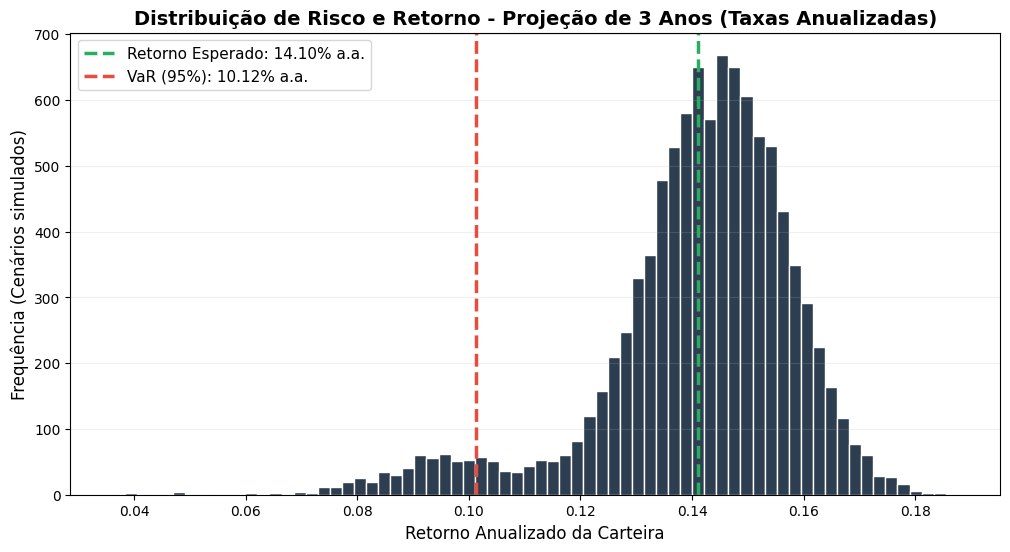

In [8]:
import pandas as pd
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt

# ==========================================
#Importação dos dados 
df_top15 = pd.read_excel(r"C:\Users\henri\.vscode\vscode\Finanças + Python\Base de Dados Finanças\Top 15 Ativos.xlsx")

CAPITAL_INICIAL = 50000000
NUM_SIMULACOES = 10000
ANOS = 3 # <-- Agora a simulação considera o risco acumulado em 3 anos!
np.random.seed(42)

CDI_MEDIO_ESPERADO = 0.105 
VOLATILIDADE_CDI = 0.02

tabela_pd = {
    'AAA': 0.001, 'AA': 0.003, 'A': 0.005, 'A-': 0.008,
    'BBB': 0.015, 'BB+': 0.025, 'BB': 0.04, 'BB-': 0.06
}

# ==========================================
# Otimização de Carteira
spreads_top15 = df_top15['Spread (bps)'].values / 10000 
def objective(w):
    return -np.sum(w * spreads_top15)

constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0})

bounds = []
for idx, row in df_top15.iterrows():
    try:
        ticket_min = (row['Ticket Mín (R$ mil)'] * 1000) / CAPITAL_INICIAL
    except KeyError:
        ticket_min = 0.0
    bounds.append((ticket_min, 0.20))

w0 = np.ones(15) / 15 
resultado = minimize(objective, w0, method='SLSQP', bounds=bounds, constraints=constraints)
pesos_otimizados = resultado.x
df_top15['Peso Otimizado'] = pesos_otimizados

# ==========================================
#Simulação de Monte Carlo para 3 anos
prob_default_anual = np.array([tabela_pd.get(r, 0.10) for r in df_top15['Rating Interno']])

# Probabilidade de dar calote em algum momento nos próximos 3 anos
pd_acumulada = 1 - (1 - prob_default_anual)**ANOS

ltvs = df_top15['LTV - Loan to Value (%)'].values / 100
lgd = ltvs * 0.5 
tem_alienacao = df_top15['Garantia'].str.contains('Alienação', case=False, na=False).values
lgd = np.where(tem_alienacao, lgd * 0.7, lgd)

cdi_por_ano = np.random.normal(CDI_MEDIO_ESPERADO, VOLATILIDADE_CDI, (NUM_SIMULACOES, ANOS))
cdi_acumulado = np.prod(1 + cdi_por_ano, axis=1)
cdi_anualizado_cenarios = cdi_acumulado**(1/ANOS) - 1

# Sorteio dos calotes baseado na probabilidade acumulada de 3 anos
matriz_calotes = np.random.rand(NUM_SIMULACOES, 15) < pd_acumulada

# Retornos (Anualizados para facilitar a leitura)
retorno_pagamento_aa = cdi_anualizado_cenarios[:, np.newaxis] + spreads_top15

# Se der calote nos 3 anos, ele toma o LGD. 
# A rentabilidade anualizada desse prejuízo é (1 - Perda)^(1/Anos) - 1
retorno_calote_aa = (1 - lgd)**(1/ANOS) - 1

retorno_final_ativos_aa = np.where(matriz_calotes, retorno_calote_aa, retorno_pagamento_aa)

retorno_carteira_aa = np.dot(retorno_final_ativos_aa, pesos_otimizados)

# ==========================================
# Métricas estatísticas 
retorno_esperado_aa = np.mean(retorno_carteira_aa)
var_95_aa = np.percentile(retorno_carteira_aa, 5)
cvar_95_aa = np.mean(retorno_carteira_aa[retorno_carteira_aa <= var_95_aa])

# 1. Probabilidade de Perda (Retorno Nominal Abaixo de Zero)
prob_perda = np.mean(retorno_carteira_aa < 0) * 100

retornos_ruins = retorno_carteira_aa[retorno_carteira_aa < CDI_MEDIO_ESPERADO]
downside_deviation = np.std(retornos_ruins) if len(retornos_ruins) > 0 else 0.0001
sortino_ratio = (retorno_esperado_aa - CDI_MEDIO_ESPERADO) / downside_deviation

print(f"\n=== RESULTADOS: MONTE CARLO PROJEÇÃO {ANOS} ANOS (Dados Anualizados) ===")
print(f"Retorno Esperado Médio : {retorno_esperado_aa*100:.2f}% a.a.")
print(f"VaR (95%)              : {var_95_aa*100:.2f}% a.a. (Pior 5% dos cenários)")
print(f"CVaR / Shortfall       : {cvar_95_aa*100:.2f}% a.a.")
print(f"-------------------------------------------------------")
print(f"Índice de Sortino      : {sortino_ratio:.2f} (Quanto maior, melhor o retorno face ao risco de calote)")
print(f"Prob. de Dar Prejuízo  : {prob_perda:.2f}% (Chance de rentabilidade negativa após {ANOS} anos)")

# Plotagem do Histograma Assimétrico
plt.figure(figsize=(12, 6))
plt.hist(retorno_carteira_aa, bins=70, color='#2c3e50', edgecolor='white')
plt.axvline(retorno_esperado_aa, color='#27ae60', linestyle='dashed', linewidth=2.5, label=f'Retorno Esperado: {retorno_esperado_aa*100:.2f}% a.a.')
plt.axvline(var_95_aa, color='#e74c3c', linestyle='dashed', linewidth=2.5, label=f'VaR (95%): {var_95_aa*100:.2f}% a.a.')
plt.title(f'Distribuição de Risco e Retorno - Projeção de {ANOS} Anos (Taxas Anualizadas)', fontsize=14, fontweight='bold')
plt.xlabel('Retorno Anualizado da Carteira', fontsize=12)
plt.ylabel('Frequência (Cenários simulados)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(axis='y', alpha=0.2)
plt.show()

O Sharpe penaliza volatilidade para cima também. Como estamos analisando Crédito Privado, volatilidade pra cima não existe (o teto é o juro). Por isso adicionei o Índice de Sortino, que mede a qualidade da carteira apenas contra o 'Downside Deviation' (Risco de Cauda).

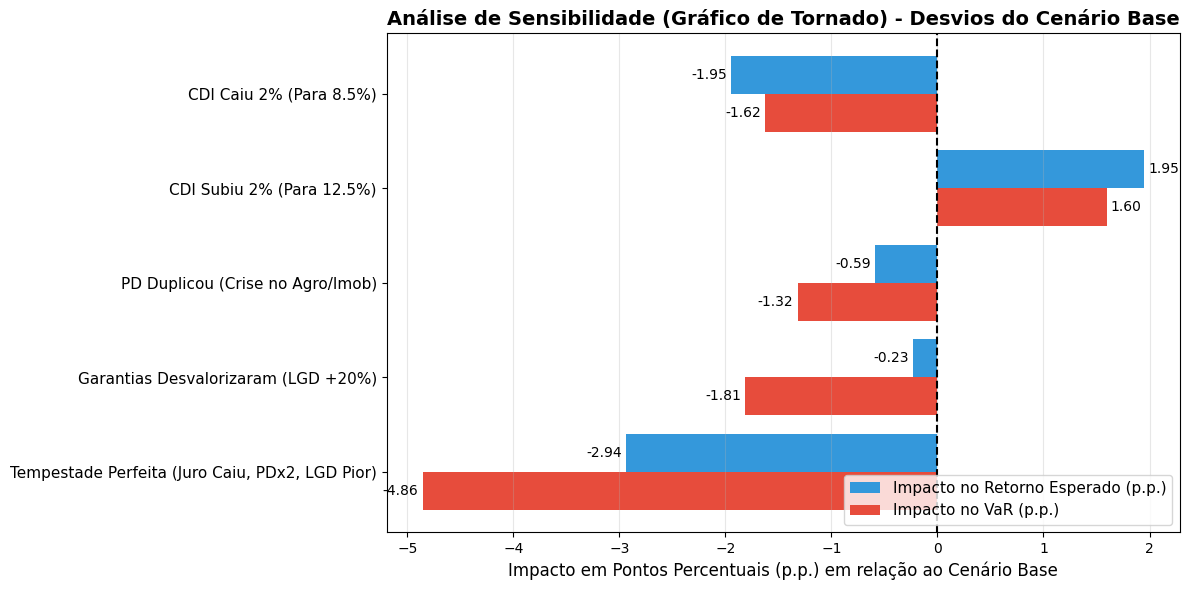

=== RESUMO DA ANÁLISE DE SENSIBILIDADE ===
Cenário Base -> Retorno: 14.10% | VaR: 10.12%
--------------------------------------------------
CDI Caiu 2% (Para 8.5%)                  -> Retorno: 12.15% | VaR:  8.50%
CDI Subiu 2% (Para 12.5%)                -> Retorno: 16.05% | VaR: 11.72%
PD Duplicou (Crise no Agro/Imob)         -> Retorno: 13.51% | VaR:  8.80%
Garantias Desvalorizaram (LGD +20%)      -> Retorno: 13.87% | VaR:  8.31%
Tempestade Perfeita (Juro Caiu, PDx2, LGD Pior) -> Retorno: 11.16% | VaR:  5.26%


In [9]:
#Análise de Sensibilidade: O que machuca mais o portfolio: o aumento de 1% na taxa Selic/CDI, ou o aumento de 1% na inadimplência?

def cenario_esperado(cdi_esperado, pd_multiplicador, lgd_piorado):
    np.random.seed(42)
    Numero_de_Simulações = 10000
    ANOS = 3
    VOL_CDI = 0.02

    #Ajuste de premissas 
    pd_anual_stress = np.clip(prob_default_anual * pd_multiplicador, 0, 1)
    pd_acumulada_stress = 1 - (1 - pd_anual_stress)**ANOS

    # Se lgd_piorado for True, assumimos que as garantias desvalorizaram 20% a mais
    lgd_stress = np.clip(lgd + 0.20, 0, 1) if lgd_piorado else lgd

    #Matrizes:
    cdi_por_ano = np.random.normal(cdi_esperado, VOL_CDI, (Numero_de_Simulações, ANOS))
    cdi_anualizado = (np.prod(1 + cdi_por_ano, axis=1))**(1/ANOS) - 1
    
    matriz_calotes = np.random.rand(Numero_de_Simulações, 15) < pd_acumulada_stress
    
    retorno_pagamento = cdi_anualizado[:, np.newaxis] + spreads_top15
    retorno_calote = (1 - lgd_stress)**(1/ANOS) - 1
    
    retorno_final = np.where(matriz_calotes, retorno_calote, retorno_pagamento)
    retorno_carteira = np.dot(retorno_final, pesos_otimizados)
    
    retorno_medio = np.mean(retorno_carteira)
    var_95 = np.percentile(retorno_carteira, 5)
    
    return retorno_medio, var_95

#Definindo os cenários de estresse
ret_base, var_base = cenario_esperado(0.105, 1.0, False)

cenarios = {
    'CDI Caiu 2% (Para 8.5%)': cenario_esperado(0.085, 1.0, False),
    'CDI Subiu 2% (Para 12.5%)': cenario_esperado(0.125, 1.0, False),
    'PD Duplicou (Crise no Agro/Imob)': cenario_esperado(0.105, 2.0, False),
    'Garantias Desvalorizaram (LGD +20%)': cenario_esperado(0.105, 1.0, True),
    'Tempestade Perfeita (Juro Caiu, PDx2, LGD Pior)': cenario_esperado(0.085, 2.0, True)
}

# ==========================================
# 3. PREPARANDO OS DADOS PARA O GRÁFICO (TORNADO)
# ==========================================
labels = list(cenarios.keys())
impacto_retorno = [(cenarios[c][0] - ret_base) * 100 for c in labels]
impacto_var = [(cenarios[c][1] - var_base) * 100 for c in labels]

# ==========================================
# 4. PLOTAGEM DO GRÁFICO DE TORNADO
# ==========================================
fig, ax = plt.subplots(figsize=(12, 6))

# Posição no eixo Y
y_pos = np.arange(len(labels))

# Barras horizontais (Tornado)
barras_ret = ax.barh(y_pos - 0.2, impacto_retorno, height=0.4, align='center', color='#3498db', label='Impacto no Retorno Esperado (p.p.)')
barras_var = ax.barh(y_pos + 0.2, impacto_var, height=0.4, align='center', color='#e74c3c', label='Impacto no VaR (p.p.)')

ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=11)
ax.invert_yaxis()  # Lê-se de cima para baixo
ax.set_xlabel('Impacto em Pontos Percentuais (p.p.) em relação ao Cenário Base', fontsize=12)
ax.set_title('Análise de Sensibilidade (Gráfico de Tornado) - Desvios do Cenário Base', fontsize=14, fontweight='bold')
ax.axvline(0, color='black', linewidth=1.5, linestyle='--') # A linha central (Cenário Base zero)

# Adicionando os valores nas pontas das barras para ficar profissional
ax.bar_label(barras_ret, fmt='%.2f', padding=3, fontsize=10)
ax.bar_label(barras_var, fmt='%.2f', padding=3, fontsize=10)

ax.legend(loc='lower right', fontsize=11)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Resumo em texto
print("=== RESUMO DA ANÁLISE DE SENSIBILIDADE ===")
print(f"Cenário Base -> Retorno: {ret_base*100:.2f}% | VaR: {var_base*100:.2f}%")
print("-" * 50)
for c, (r, v) in cenarios.items():
    print(f"{c:<40} -> Retorno: {r*100:>5.2f}% | VaR: {v*100:>5.2f}%")

Através da análise de sensibilidade, a nossa carteira está blindada contra falhas nas garantias (LGD), porque já filtramos efeitos colaterais muito fortes. A nossa verdadeira vulnerabilidade, representada pela maior barra no gráfico de tornado, é um cenário de Tempestade Perfeita: uma queda drástica nos juros (reduzindo a nossa receita nominal indexada ao CDI) combinada simultaneamente com o dobro de calotes na praça. Contudo, mesmo neste cenário de stress extremo, o nosso VaR raramente fica negativo, provando a resiliência estrutural da alocação.

------------------------------------------------------------------------------------------------------------------------------------------

Análise de Retorno vs Liquidez

--- TOP 10 ATIVOS: MAIOR EFICIÊNCIA RETORNO-LIQUIDEZ ---


,ID,Nome do Ativo,Rating Interno,Duration (anos),Spread (bps),Score_Liquidez
27,28,CRA Arroz Irrigado RS,BB+,3.0,650,48.181818
49,50,CRA Tabaco Export RS,A-,2.0,450,67.454545
41,42,CRA Semente Híbrida,BBB,3.0,550,54.181818
5,6,CRA Proteína Animal Export,BB+,3.8,700,42.363636
28,29,CRI Self Storage SP,BBB,3.2,550,52.727273
45,46,CRA Leite UHT,BB+,3.0,600,48.181818
23,24,CRA Soja Processada,A,2.2,400,72.000000
7,8,CRA Cooperativa Grãos Sul,A-,2.5,450,63.818182
11,12,CRA Algodão MT,BBB,2.8,500,55.636364
24,25,CRI Educação Superior,A-,3.0,450,60.181818


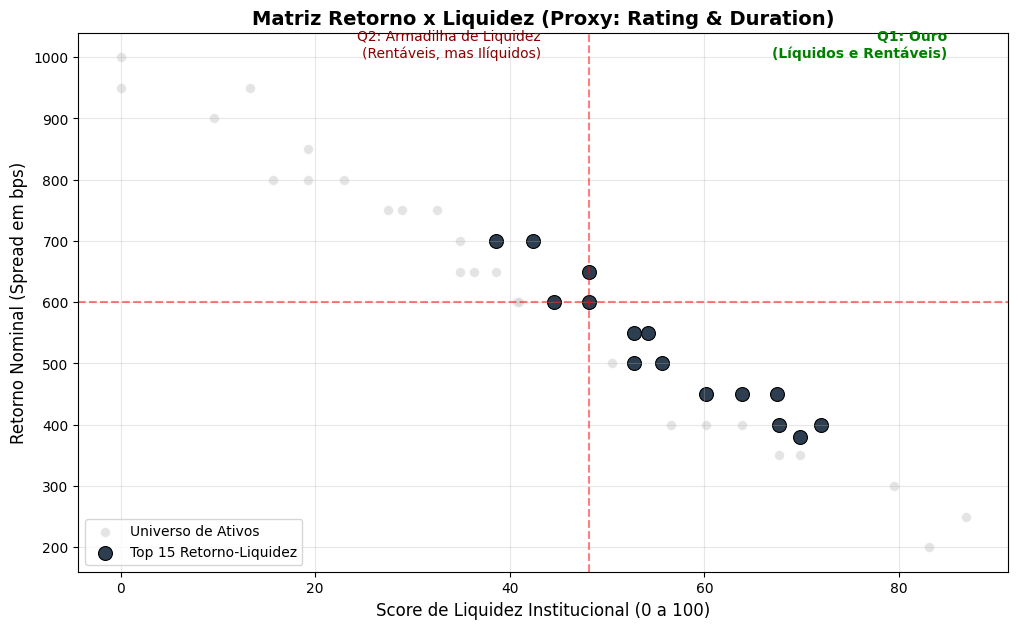

In [10]:
import seaborn as sns 
# Carregamento de Dados: 

rating_map = {'AAA': 10, 'AA': 9, 'A': 8, 'A-': 7, 'BBB': 6, 'BB+': 5, 'BB': 4, 'BB-': 3, 'B+': 2, 'B': 1, 'B-': 0}
df['Score_Rating'] = df['Rating Interno'].map(rating_map)

df = df.dropna(subset=['Duration (anos)', 'Spread (bps)', 'Score_Rating'])

# 2. Construindo a Métrica (Proxy) de Liquidez (0 a 100)
# Passo A: Normalizar o Rating (0 a 1)
rating_norm = df['Score_Rating'] / df['Score_Rating'].max()

# Passo B: Normalizar a Duration (Inversa)
# Queremos que Duration MENOR signifique Liquidez MAIOR.
duration_max = df['Duration (anos)'].max()
duration_norm = 1 - (df['Duration (anos)'] / duration_max)

# Passo C: O Score Final (Peso 60% para Rating, 40% para Prazo)
PESO_RATING = 0.6
PESO_PRAZO = 0.4
df['Score_Liquidez'] = ((rating_norm * PESO_RATING) + (duration_norm * PESO_PRAZO)) * 100

# 3. O Fator Retorno-Liquidez (Maximizar isto)
# Equação: Spread * Score_Liquidez. 
# Valoriza ativos que pagam bem SEM trancar o dinheiro por muito tempo
df['Fator_Retorno_Liquidez'] = df['Spread (bps)'] * df['Score_Liquidez']

# Top 15 mais eficientes em Retorno-Liquidez
top_15_liquidez = df.sort_values(by='Fator_Retorno_Liquidez', ascending=False).head(15)

# 4. Exibição Tabela
print("--- TOP 10 ATIVOS: MAIOR EFICIÊNCIA RETORNO-LIQUIDEZ ---")
colunas = ['ID', 'Nome do Ativo', 'Rating Interno', 'Duration (anos)', 'Spread (bps)', 'Score_Liquidez']
display(top_15_liquidez[colunas].head(10))

# 5. Visualização (Gráfico de Quadrantes para Apresentação)
plt.figure(figsize=(12, 7))

# Definindo as medianas para traçar os quadrantes
mediana_liquidez = df['Score_Liquidez'].median()
mediana_spread = df['Spread (bps)'].median()

# Plota todos os ativos em cinza
sns.scatterplot(x=df['Score_Liquidez'], y=df['Spread (bps)'], color='lightgrey', alpha=0.6, s=50, label='Universo de Ativos') #type: ignore

# Plota os Top 15 em destaque
sns.scatterplot(x=top_15_liquidez['Score_Liquidez'], y=top_15_liquidez['Spread (bps)'], color='#2c3e50', s=100, edgecolor='black', label='Top 15 Retorno-Liquidez') #type: ignore

# Linhas dos quadrantes
plt.axvline(mediana_liquidez, color='red', linestyle='--', alpha=0.5)
plt.axhline(mediana_spread, color='red', linestyle='--', alpha=0.5)

# Anotações para guiar o Comité de Gestão
plt.text(85, df['Spread (bps)'].max(), 'Q1: Ouro\n(Líquidos e Rentáveis)', fontsize=10, color='green', fontweight='bold', ha='right')
plt.text(mediana_liquidez - 5, df['Spread (bps)'].max(), 'Q2: Armadilha de Liquidez\n(Rentáveis, mas Ilíquidos)', fontsize=10, color='darkred', ha='right')

plt.title('Matriz Retorno x Liquidez (Proxy: Rating & Duration)', fontsize=14, fontweight='bold')
plt.xlabel('Score de Liquidez Institucional (0 a 100)', fontsize=12)
plt.ylabel('Retorno Nominal (Spread em bps)', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Otimização por Cálculo Diferencial e Integral multivariável

In [11]:
import pandas as pd
import numpy as np
import pulp

#Importação dos dados 

caminho_arquivo = r"C:\Users\henri\.vscode\vscode\Finanças + Python\Base de Dados Finanças\Base de Dados - Case.xlsx"
df_ltv = pd.read_excel(caminho_arquivo, sheet_name='LTV -100')
df_ltv = df_ltv.dropna(subset=['Duration (anos)', 'Spread (bps)', 'Rating Interno']).reset_index(drop=True)

# ==========================================
# Mapeamento de risco e crédio, além da limpeza
# Aplicamos o comando .fillna() para lidar com possívels valores ausentes e erros de conta, prejudicando a análise. 

# Transforma a qualidade de crédito num Score (0 a 10)
rating_map = {'AAA': 10, 'AA': 9, 'A': 8, 'A-': 7, 'BBB': 6, 'BB+': 5, 'BB': 4, 'BB-': 3, 'B+': 2, 'B': 1, 'B-': 0}

# Probabilidade de Default (PD) estatística baseada no Rating
tabela_pd = {'AAA': 0.001, 'AA': 0.003, 'A': 0.005, 'A-': 0.008, 'BBB': 0.015, 'BB+': 0.025, 'BB': 0.04, 'BB-': 0.06, 'B+': 0.12, 'B': 0.20, 'B-': 0.30}

df_ltv['Score_Rating'] = df_ltv['Rating Interno'].map(rating_map).fillna(5)  # Valor médio para ratings não mapeados
df_ltv['Prob_Default'] = df_ltv['Rating Interno'].map(tabela_pd).fillna(0.10) # Assumindo 10% para ratings não mapeados

# ==========================================
# 3. Normalização dos Fatores para a Função de Utilidade do Cálculo Diferencial e Integral Multivariável
# ==========================================
# Para o cálculo diferencial funcionar, Retorno, Liquidez e Risco precisam estar 
# na mesma escala (de 0 a 1). Se não fizermos isso, o Spread (que está na casa dos 400) 
# vai esmagar matematicamente a Liquidez (que é um score pequeno).

# A. Normalização do Retorno (Quanto maior o Spread, mais próximo de 1)
spreads = df_ltv['Spread (bps)']
if spreads.max() == spreads.min():
    df_ltv['Retorno_Norm'] = 0.5  # Valor neutro se não há variação
else:
    df_ltv['Retorno_Norm'] = (spreads - spreads.min()) / (spreads.max() - spreads.min())

# B. Normalização da Liquidez (Combinação de bom Rating e Prazo Curto)
rating_norm_liq = df_ltv['Score_Rating'] / df_ltv['Score_Rating'].max()
duration_norm_liq = 1 - (df_ltv['Duration (anos)'] / df_ltv['Duration (anos)'].max())
df_ltv['Score_Liquidez'] = (rating_norm_liq * 0.5) + (duration_norm_liq * 0.5)

liq = df_ltv['Score_Liquidez']
if abs(liq.max() - liq.min()) < 1e-10:  # Tolerância para evitar divisão por quase-zero
    df_ltv['Liquidez_Norm'] = 0.5  # Valor neutro se não há variação
else:
    df_ltv['Liquidez_Norm'] = (liq - liq.min()) / (liq.max() - liq.min())

# C. Normalização da Segurança (O INVERSO do Risco: Quanto menor a PD, mais próximo de 1)
pds = df_ltv['Prob_Default']
if pds.max() == pds.min():
    df_ltv['Seguranca_Norm'] = 0.5  # Valor neutro
else:
    df_ltv['Seguranca_Norm'] = 1 - ((pds - pds.min()) / (pds.max() - pds.min()))

# ==========================================
# 4. A FUNÇÃO DE UTILIDADE MULTIVARIÁVEL:
# ==========================================
# O Gestor calibra e decide os pesos: O que importa mais para o Fundo agora?
# Aqui está a equação de Utilidade (U) que será maximizada.
PESO_RETORNO = 0.30
PESO_LIQUIDEZ = 0.10
PESO_SEGURANCA = 0.50

# U(x) = (Retorno * 0.3) + (Liquidez * 0.2) + (Segurança * 0.5)
df_ltv['Utilidade_Final'] = (df_ltv['Retorno_Norm'] * PESO_RETORNO) + \
                        (df_ltv['Liquidez_Norm'] * PESO_LIQUIDEZ) + \
                        (df_ltv['Seguranca_Norm'] * PESO_SEGURANCA)

# Se ainda houver NaN, substituir por 0 (último recurso de limpeza de dados)
df_ltv['Utilidade_Final'] = df_ltv['Utilidade_Final'].fillna(0.0)

# ==========================================
# 5. OTIMIZAÇÃO MATEMÁTICA (com PuLP --> Biblioteca do Python)
# ==========================================
capital_total = 50_000_000
ativos = df_ltv.index.tolist()

# Define que o objetivo da nossa Álgebra é MAXIMIZAR a função
prob = pulp.LpProblem("Otimizacao_Multi_Objetivo", pulp.LpMaximize)

# Variáveis do Cálculo:
# w: Variável Contínua. É o percentual financeiro exato que o ativo vai receber (0 a 20%).
# y: Variável Binária Inteira. Serve como "interruptor" (1 = Ativo comprado, 0 = Ativo rejeitado).
w = pulp.LpVariable.dicts("peso", ativos, lowBound=0, upBound=0.10, cat='Continuous')
y = pulp.LpVariable.dicts("selecionado", ativos, cat='Binary')

# 5.1. A Equação Objetivo: Somatório(Utilidade do Ativo * Peso do Ativo na Carteira)
prob += pulp.lpSum([df_ltv.loc[i, 'Utilidade_Final'] * w[i] for i in ativos])

# 5.2. As Restrições (Multiplicadores de Lagrange/Limites do Fundo):
# Restrição A: O portfólio tem que usar exatamente 100% (1.0) do dinheiro.
prob += pulp.lpSum([w[i] for i in ativos]) == 1.0

# Restrição B: A soma dos "interruptores" ligados tem que ser maior ou igual a 15 ativos.
prob += pulp.lpSum([y[i] for i in ativos]) >= 15

# Restrição C: Limite por Setor - "No máximo 35% em um único setor"
setores_unicos = df_ltv['Setor'].unique()
for setor_atual in setores_unicos:
    # A soma dos pesos de todos os ativos que pertencem a este setor não pode passar de 0.35 (35%)
    prob += pulp.lpSum([w[i] for i in ativos if df_ltv.loc[i, 'Setor'] == setor_atual]) <= 0.35

# Restrição D: Limite de Rating - "No máximo 25% em B+ ou inferior"
# Scores: B+=2, B=1, B-=0. Então Score_Rating <= 2
prob += pulp.lpSum([w[i] for i in ativos if df_ltv.loc[i, 'Score_Rating'] <= 2]) <= 0.25

# Restrição E: Duration Média Ponderada - "Entre 2.0 e 4.0 anos"
prob += pulp.lpSum([w[i] * df_ltv.loc[i, 'Duration (anos)'] for i in ativos]) >= 2.0
prob += pulp.lpSum([w[i] * df_ltv.loc[i, 'Duration (anos)'] for i in ativos]) <= 4.0

# Restrição F: Liquidez Mínima - "Mínimo 10% em liquidez Alta/Média (Liquidez_Norm >= 0.5)"
prob += pulp.lpSum([w[i] for i in ativos if df_ltv.loc[i, 'Liquidez_Norm'] >= 0.5]) >= 0.10

# # Restrições G: Limites Individuais por Ativo
for i in ativos:
    # Trava Lógica: O peso 'w' só pode ser maior que 0 se o interruptor 'y' estiver em 1.
    prob += w[i] <= 0.20 * y[i] # Máximo de 20% - Restrição de Alocação Individual
    
    # Respeitar o Ticket Mínimo de cada ativo
    try:
        ticket_min_pct = (df_ltv.loc[i, 'Ticket Mín (R$ mil)'] * 1000) / capital_total
    except:
        ticket_min_pct = 0
    prob += w[i] >= ticket_min_pct * y[i]

# Resolver a equação
prob.solve()

# ==========================================
# 6. EXIBIÇÃO DOS RESULTADOS: A Carteira Otimizada
# ==========================================
print(f"Status do Solver: {pulp.LpStatus[prob.status]}")
print("=== CARTEIRA OTIMIZADA: RETORNO x LIQUIDEZ x SEGURANÇA ===\n")
print(" === CÁLCULO DIFERENCIAL E INTEGRAL MULTIVARIÁVEL APLICADO A OTIMIZAÇÃO DE CARTEIRA ===\n")

# Filtra apenas os ativos que o algoritmo decidiu comprar (peso > 0)
pesos_finais = []
for i in ativos:
    if w[i].varValue is not None and w[i].varValue > 0.001:
        pesos_finais.append({
            'ID': df_ltv.loc[i, 'ID'],
            'Nome': df_ltv.loc[i, 'Nome do Ativo'],
            'Setor': df_ltv.loc[i, 'Setor'],
            'Rating': df_ltv.loc[i, 'Rating Interno'],
            'Spread': df_ltv.loc[i, 'Spread (bps)'],
            'Peso (%)': w[i].varValue * 100,
            'Utilidade': df_ltv.loc[i, 'Utilidade_Final']
        })

#Salvamento dos dados em um dataframe (pd.Dataframe()) e carregamento do do dataframe em Excel (entregável final)
df_carteira = pd.DataFrame(pesos_finais).sort_values(by='Peso (%)', ascending=False)
display(df_carteira.round(2))

print(f"\nTotal de Ativos Selecionados: {len(df_carteira)}")

df_carteira.to_excel(r"C:\Users\henri\.vscode\vscode\Finanças + Python\Base de Dados Finanças\Carteira Otimizada.xlsx", index=False)

Status do Solver: Optimal
=== CARTEIRA OTIMIZADA: RETORNO x LIQUIDEZ x SEGURANÇA ===

 === CÁLCULO DIFERENCIAL E INTEGRAL MULTIVARIÁVEL APLICADO A OTIMIZAÇÃO DE CARTEIRA ===



,ID,Nome,Setor,Rating,Spread,Peso (%),Utilidade
1,8,CRA Cooperativa Grãos Sul,Agronegócio,A-,450,10.0,0.69
2,17,CRI Galpão Last-Mile RJ,Logística,A,380,10.0,0.66
4,25,CRI Educação Superior,Educação,A-,450,10.0,0.67
6,27,CRI Parque Industrial MG,Industrial,A,400,10.0,0.67
13,46,CRA Leite UHT,Laticínios,BB+,600,10.0,0.67
14,50,CRA Tabaco Export RS,Agronegócio,A-,450,10.0,0.70
7,29,CRI Self Storage SP,Autoarmazenagem,BBB,550,10.0,0.69
11,42,CRA Semente Híbrida,Agronegócio,BBB,550,10.0,0.69
12,45,CRI Residencial Médio Padrão,Residencial,A-,400,9.8,0.65
3,24,CRA Soja Processada,Agronegócio,A,400,5.0,0.68



Total de Ativos Selecionados: 15


=== SIMULAÇÃO DE DISTRIBUIÇÃO - CARTEIRA OTIMIZADA ===
Horizonte: Anualizado (taxas anualizadas)

Retorno Esperado Médio : 14.02% a.a.
VaR (95%)              : 10.01% a.a.
CVaR (95%)             : 8.31% a.a.
--------------------------------------------------
Índice de Sortino      : 2.20
Prob. de Rentabilidade Negativa : 0.00%


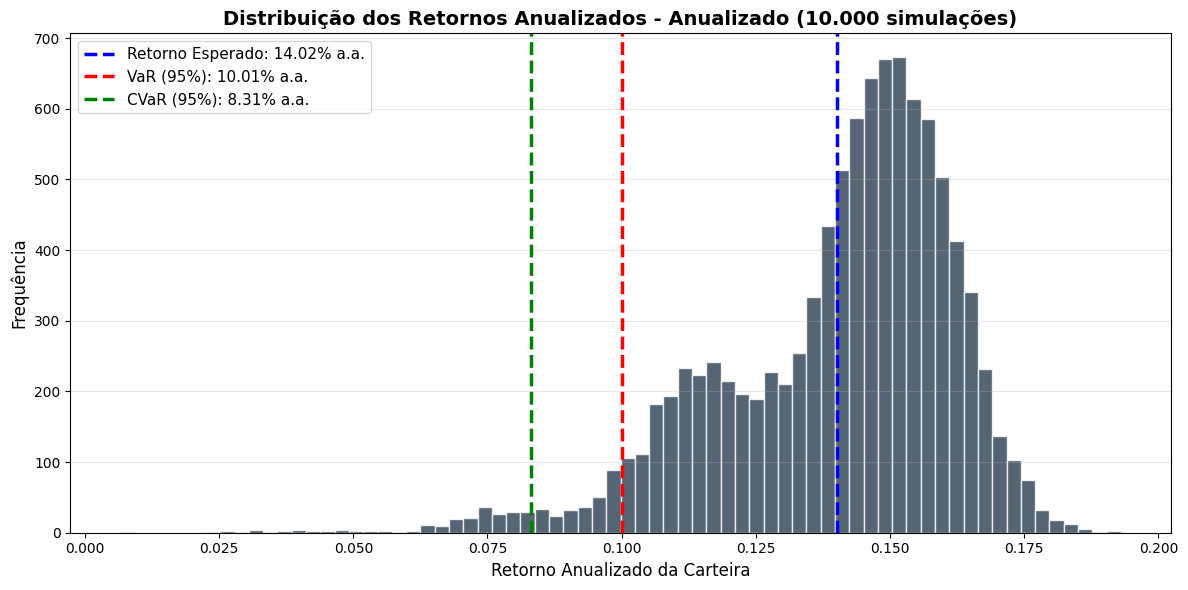

In [12]:
import matplotlib.pyplot as plt

# ==========================================
# 1. CARREGAMENTO DA CARTEIRA OTIMIZADA
# ==========================================
df = pd.read_excel(r"C:\Users\henri\.vscode\vscode\Finanças + Python\Base de Dados Finanças\Carteira Otimizada.xlsx")
# Garantir que os pesos estejam em decimal e que somem 1
pesos = df['Peso (%)'].values / 100
spreads = df['Spread'].values / 10000  # bps para decimal

# ==========================================
# 2. PARÂMETROS DA SIMULAÇÃO
# ==========================================
CAPITAL_INICIAL = 50_000_000
NUM_SIMULACOES = 10000
ANOS = 3
CDI_MEDIO_ESPERADO = 0.105
VOLATILIDADE_CDI = 0.02
np.random.seed(42)  # reprodutibilidade

# Mapeamento de rating para PD anual (fonte: tabela institucional)
tabela_pd = {
    'AAA': 0.001, 'AA': 0.003, 'A': 0.005, 'A-': 0.008,
    'BBB': 0.015, 'BB+': 0.025, 'BB': 0.04, 'BB-': 0.06,
    'B+': 0.12, 'B': 0.20, 'B-': 0.30
}
# PD anual para cada ativo (rating disponível na coluna 'Rating')
pd_anual = np.array([tabela_pd.get(r, 0.10) for r in df['Rating']])

# PD acumulada em 3 anos
pd_acumulada = 1 - (1 - pd_anual) ** ANOS

# LGD conservadora (50% de perda em caso de default)
LGD = 0.50

# ==========================================
# 3. SIMULAÇÃO DE MONTE CARLO
# ==========================================
# Geração do CDI para cada ano e cada cenário
cdi_por_ano = np.random.normal(CDI_MEDIO_ESPERADO, VOLATILIDADE_CDI,
                               (NUM_SIMULACOES, ANOS))
cdi_acumulado = np.prod(1 + cdi_por_ano, axis=1)
cdi_anualizado = cdi_acumulado ** (1/ANOS) - 1

# Matriz de default (True = calote no período)
matriz_calotes = np.random.rand(NUM_SIMULACOES, len(df)) < pd_acumulada

# Retorno no cenário sem default: CDI anualizado + spread
retorno_pagamento = cdi_anualizado[:, np.newaxis] + spreads
# Retorno no cenário de default: perda do LGD anualizada
retorno_calote = (1 - LGD) ** (1/ANOS) - 1

# Combinação dos cenários
retorno_final_ativos = np.where(matriz_calotes, retorno_calote, retorno_pagamento)

# Retorno da carteira (média ponderada pelos pesos)
retorno_carteira = np.dot(retorno_final_ativos, pesos)

# ==========================================
# 4. MÉTRICAS ESTATÍSTICAS
# ==========================================
retorno_esperado = np.mean(retorno_carteira)
var_95 = np.percentile(retorno_carteira, 5)
cvar_95 = np.mean(retorno_carteira[retorno_carteira <= var_95])

# Índice de Sortino (considerando CDI como taxa mínima aceitável)
retornos_abaixo_cdi = retorno_carteira[retorno_carteira < CDI_MEDIO_ESPERADO]
downside_dev = np.std(retornos_abaixo_cdi) if len(retornos_abaixo_cdi) > 0 else 0.0001
sortino = (retorno_esperado - CDI_MEDIO_ESPERADO) / downside_dev

prob_perda = np.mean(retorno_carteira < 0) * 100

# ==========================================
# 5. EXIBIÇÃO DOS RESULTADOS
# ==========================================
print("=== SIMULAÇÃO DE DISTRIBUIÇÃO - CARTEIRA OTIMIZADA ===")
print(f"Horizonte: Anualizado (taxas anualizadas)\n")
print(f"Retorno Esperado Médio : {retorno_esperado*100:.2f}% a.a.")
print(f"VaR (95%)              : {var_95*100:.2f}% a.a.")
print(f"CVaR (95%)             : {cvar_95*100:.2f}% a.a.")
print("-" * 50)
print(f"Índice de Sortino      : {sortino:.2f}")
print(f"Prob. de Rentabilidade Negativa : {prob_perda:.2f}%")

# ==========================================
# 6. GRÁFICO DE HISTOGRAMA
# ==========================================
plt.figure(figsize=(12, 6))
plt.hist(retorno_carteira, bins=70, color='#2c3e50', edgecolor='white', alpha=0.8)

plt.axvline(retorno_esperado, color='blue', linestyle='dashed', linewidth=2.5,
            label=f'Retorno Esperado: {retorno_esperado*100:.2f}% a.a.')
plt.axvline(var_95, color='red', linestyle='dashed', linewidth=2.5,
            label=f'VaR (95%): {var_95*100:.2f}% a.a.')
plt.axvline(cvar_95, color='green', linestyle='dashed', linewidth=2.5,
            label=f'CVaR (95%): {cvar_95*100:.2f}% a.a.')

plt.title(f'Distribuição dos Retornos Anualizados - Anualizado (10.000 simulações)',
          fontsize=14, fontweight='bold')
plt.xlabel('Retorno Anualizado da Carteira', fontsize=12)
plt.ylabel('Frequência', fontsize=12)
plt.legend(fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Corrigindo erros da otimização por Cálculo Diferencial e Integral:

1) Distribuição dos pesos de forma linear causando problemas na alocação, perdendo retornos
2) O Código realiza a otimização, porém restrito pela parede de restrição linear ativa

In [13]:
import pandas as pd 
import numpy as np 

# ========================================
# Importação dos dados: Caminho + Dataset/Frame e limpeza de dados

caminho_arquivo = r"C:\Users\henri\.vscode\vscode\Finanças + Python\Base de Dados Finanças\Base de Dados - Case.xlsx"
df_ltv = pd.read_excel(caminho_arquivo, sheet_name='LTV -100')
df_ltv = df_ltv.dropna(subset=['Duration (anos)', 'Spread (bps)', 'Rating Interno']).reset_index(drop=True)

#Mapeamento de risco
rating_map = {'AAA': 10, 'AA': 9, 'A': 8, 'A-': 7, 
              'BBB': 6, 'BB+': 5, 'BB': 4, 'BB-': 3, 'B+': 2, 'B': 1, 'B-': 0}
tabela_pd = {'AAA': 0.001, 'AA': 0.003, 'A': 0.005, 'A-': 0.008, 
             'BBB': 0.015, 'BB+': 0.025, 'BB': 0.04, 'BB-': 0.06, 'B+': 0.12, 'B': 0.20, 'B-': 0.30}

df_ltv['Score_Rating'] = df_ltv['Rating Interno'].map(rating_map).fillna(5)
df_ltv['Prob_Default_Anual'] = df_ltv['Rating Interno'].map(tabela_pd).fillna(0.10) 
#O comando .fillna() é utilizado para lidar com valores ausentes (NaN) que podem surgir durante a limpeza de dados

# Normalização dos dados a fim de evitar que o Spread (um valor maior) domine matematicamente a liquidez (score menor)
rating_norm = df_ltv['Score_Rating'] / df_ltv['Score_Rating'].max()
duration_norm = 1 - (df_ltv['Duration (anos)'] / df_ltv['Duration (anos)'].max())
liq = (rating_norm * 0.5) + (duration_norm * 0.5)
df_ltv['Liquidez_Norm'] = (liq - liq.min()) / (liq.max() - liq.min()) if abs(liq.max() - liq.min()) >= 1e-10 else 0.5

# =========================================
# Simulação de Monte Carlo para matrizes de pesos:

S = 10000
Anos = 3
CDI_MEDIO_ESPERADO = 0.105
VOLATILIDADE_CDI = 0.02
LGD = 0.50

np.random.seed(42) #Trava a aleatoriedade para garantir que os resultados sejam reproduzíveis

num_ativos_total = len(df_ltv)
spreads_dec = df_ltv['Spread (bps)'].values / 10000
pd_acumulada = 1 - (1 - df_ltv['Prob_Default_Anual'].values)**Anos

# Matriz 1: Sorteio do CDI e Retornos sem calote
cdi_por_ano = np.random.normal(CDI_MEDIO_ESPERADO, VOLATILIDADE_CDI, (S, Anos))
cdi_anualizado_cenarios = np.prod(1 + cdi_por_ano, axis=1)**(1/Anos) - 1
retorno_pagamento_aa = cdi_anualizado_cenarios[:, np.newaxis] + spreads_dec

# Matriz 2: Retorno negativo caso haja calote
retorno_calote_aa = (1 - LGD)**(1/Anos) - 1

# Matriz 3: Sorteio das Quebras
matriz_calotes = np.random.rand(S, num_ativos_total) < pd_acumulada

# Matriz Final de Retornos (10.000 cenários x Num_Ativos)
matriz_retornos = np.where(matriz_calotes, retorno_calote_aa, retorno_pagamento_aa)

# O Segredo do CVaR: A equação de Rockafellar otimiza as PERDAS. Logo, Perda = Retorno Invertido.
matriz_perdas = -matriz_retornos
retorno_esperado_ativos = np.mean(matriz_retornos, axis=0)

print(f"✅ Monte Carlo concluído! Matriz de Perdas gerada: {matriz_perdas.shape[0]} Cenários x {matriz_perdas.shape[1]} Ativos.")

✅ Monte Carlo concluído! Matriz de Perdas gerada: 10000 Cenários x 28 Ativos.


In [ ]:
#Otimização da Carteira por CVaR: 
import pulp

capital_total = 50_000_000
ativos = df_ltv.index.tolist()
alfa = 0.95 #Intervalo de Confiança para o CVaR

# Em vez de Maximizar Utilidade, vamos MINIMIZAR o Risco de Cauda (CVaR)
prob = pulp.LpProblem("Otimizacao_CVaR_Rockafellar", pulp.LpMinimize)

# Variáveis Clássicas (Pesos e Interruptores)
w = pulp.LpVariable.dicts("peso", ativos, lowBound=0, upBound=0.20, cat='Continuous')
y = pulp.LpVariable.dicts("selecionado", ativos, cat='Binary')

# Variáveis Exclusivas do CVaR 
gamma = pulp.LpVariable("VaR", lowBound=None, cat='Continuous') #VaR Teórico
z = pulp.LpVariable.dicts("Excesso_Perda", range(S), lowBound=0, cat='Continuous') #Ls(w) - gamma

# 3.1 A Equação Objetivo (Minimizar o VaR + Média das piores perdas)
prob += gamma + (1.0 / ((1 - alfa) * S)) * pulp.lpSum([z[s] for s in range(S)])

# ==========================================
# AS RESTRIÇÕES DE CENÁRIO (Teorema de Rockafellar - Uryasev)
# ==========================================
for s in range(S):
    # Calcula qual seria a perda exata da carteira NESTE cenário específico
    perda_cenario = pulp.lpSum([matriz_perdas[s][i] * w[i] for i in ativos])
    # A variável 'z' capta apenas o prejuízo que ultrapassar a linha do VaR (gamma)
    prob += z[s] >= perda_cenario - gamma

# ==========================================
# Aplicações das restrições
# ==========================================
# Restrição A e B: Orçamento e Diversificação
prob += pulp.lpSum([w[i] for i in ativos]) == 1.0
prob += pulp.lpSum([y[i] for i in ativos]) >= 15

# Restrição C: Limite por Setor (Max 35%)
for setor_atual in df_ltv['Setor'].unique():
    prob += pulp.lpSum([w[i] for i in ativos if df_ltv.loc[i, 'Setor'] == setor_atual]) <= 0.35

# Restrição D: Limite de Rating (Max 25% em B+ ou pior)
prob += pulp.lpSum([w[i] for i in ativos if df_ltv.loc[i, 'Score_Rating'] <= 2]) <= 0.25

# Restrição E: Duration entre 2.0 e 4.0 anos
prob += pulp.lpSum([w[i] * df_ltv.loc[i, 'Duration (anos)'] for i in ativos]) >= 2.0
prob += pulp.lpSum([w[i] * df_ltv.loc[i, 'Duration (anos)'] for i in ativos]) <= 4.0

# Restrição F: Liquidez Mínima (Min 10% em Liquidez Alta)
prob += pulp.lpSum([w[i] for i in ativos if df_ltv.loc[i, 'Liquidez_Norm'] >= 0.5]) >= 0.10

# Restrição G: Limites Individuais (Big-M) e Ticket Mínimo
for i in ativos:
    prob += w[i] <= 0.20 * y[i]
    try:
        ticket_min_pct = (df_ltv.loc[i, 'Ticket Mín (R$ mil)'] * 1000) / capital_total
    except KeyError:
        ticket_min_pct = 0
    prob += w[i] >= ticket_min_pct * y[i]

# Restrição H (NOVA): Alvo de Rentabilidade
# Para o fundo não colocar tudo em AAA, exigimos um Retorno Mínimo Esperado (Ex: CDI Médio + 1.5% a.a.)
META_RETORNO = CDI_MEDIO_ESPERADO + 0.015
prob += pulp.lpSum([w[i] * retorno_esperado_ativos[i] for i in ativos]) >= META_RETORNO


# RESOLVER A EQUAÇÃO (Pode demorar entre 10s e 40s dependendo do seu CPU)
print("Iniciando o Solver MILP com 10.000 cenários estocásticos... Aguarde.")
prob.solve()

# ==========================================
# 4. EXIBIÇÃO DOS RESULTADOS
# ==========================================
print(f"\nStatus do Solver: {pulp.LpStatus[prob.status]}")
print("=== CARTEIRA OTIMIZADA POR CVaR (ROCKAFELLAR-URYASEV) ===\n")

pesos_finais = []
for i in ativos:
    if w[i].varValue is not None and w[i].varValue > 0.001:
        pesos_finais.append({
            'Nome': df_ltv.loc[i, 'Nome do Ativo'],
            'Setor': df_ltv.loc[i, 'Setor'],
            'Rating': df_ltv.loc[i, 'Rating Interno'],
            'Spread': df_ltv.loc[i, 'Spread (bps)'],
            'Retorno Esperado (%)': retorno_esperado_ativos[i] * 100,
            'Peso (%)': w[i].varValue * 100
        })

df_carteira_cvar = pd.DataFrame(pesos_finais).sort_values(by='Peso (%)', ascending=False)
display(df_carteira_cvar.round(2))
print(f"\nTotal de Ativos Selecionados: {len(df_carteira_cvar)}")

df_carteira_cvar.to_excel(r"C:\Users\henri\.vscode\vscode\Finanças + Python\Base de Dados Finanças\Carteira Otimizada.xlsx", index=False)

Iniciando o Solver MILP com 10.000 cenários estocásticos... Aguarde.

Status do Solver: Optimal
=== CARTEIRA OTIMIZADA POR CVaR (ROCKAFELLAR-URYASEV) ===



,Nome,Setor,Rating,Spread,Retorno Esperado (%),Peso (%)
5,CRI Escritório Faria Lima,Comercial,AAA,250,12.90,18.70
0,CRI Logística Norte I,Logística,A,350,13.48,6.31
10,CRI Parque Industrial MG,Industrial,A,400,13.99,6.27
7,CRA Soja Processada,Agronegócio,A,400,13.89,5.77
6,CRI Galpão Last-Mile RJ,Logística,A,380,13.78,5.74
8,CRI Educação Superior,Educação,A-,450,14.28,5.34
13,CRI Edifício Corporativo ABC,Comercial,AA,300,13.14,5.14
1,CRI Residencial SP Prime,Residencial,AA,200,12.27,5.08
16,CRI Residencial Médio Padrão,Residencial,A-,400,13.63,5.04
12,CRI Estacionamento Aeroporto,Infraestrutura,A,350,13.43,4.72



Total de Ativos Selecionados: 20


Gerando visualização de Risco de Cauda (Rockafellar-Uryasev)...


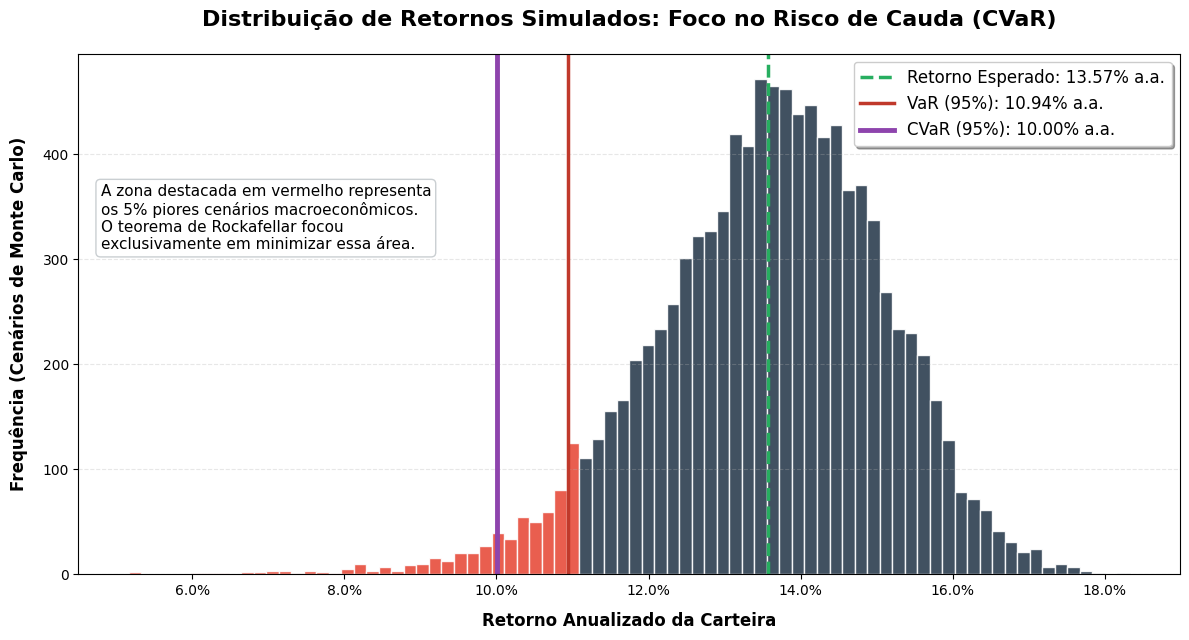

Visualização gerada com sucesso!


In [24]:
# ==========================================
#Gráficos de Retorno: 
import matplotlib.pyplot as plt 
import matplotlib.ticker as mtick

# ==============================================================================
# GERAÇÃO DO GRÁFICO INSTITUCIONAL CVaR PARA POWERPOINT
# ==============================================================================
print("Gerando visualização de Risco de Cauda (Rockafellar-Uryasev)...")

# 1. RECONSTRUÇÃO DOS RETORNOS DA CARTEIRA OTIMIZADA
# Pegamos o vetor de pesos originais do PuLP (incluindo os zeros) para alinhar com a matriz
pesos_totais_cvar = np.array([w[i].varValue for i in ativos])

# Multiplicamos a Matriz de Cenários (2000xN) pelos pesos da nova carteira
retornos_simulados_cvar = np.dot(matriz_retornos, pesos_totais_cvar)

# 2. CÁLCULO DAS MÉTRICAS DE CAUDA
retorno_esperado = np.mean(retornos_simulados_cvar)
var_95 = np.percentile(retornos_simulados_cvar, 5) # Onde começa a cauda (Pior 5%)
cvar_95 = np.mean(retornos_simulados_cvar[retornos_simulados_cvar <= var_95]) # A média da cauda

# ==============================================================================
# 3. PLOTAGEM DO GRÁFICO (ESTÉTICA INSTITUCIONAL)
# ==============================================================================
plt.figure(figsize=(12, 6.5)) # Proporção ideal para slides (16:9 widescreen)

# Criamos o histograma. O pulo do gato: salvamos os 'patches' (as barras desenhadas)
n, bins, patches = plt.hist(retornos_simulados_cvar, bins=80, color='#2c3e50', edgecolor='white', alpha=0.9)

# O TRUQUE DO GESTOR: Pintar a cauda de risco de vermelho (Expected Shortfall)
for c, p in zip(bins, patches):
    if c <= var_95:
        p.set_facecolor('#e74c3c') # Pinta de vermelho sangue tudo que for pior que o VaR

# Linhas de Demarcação Verticais
plt.axvline(retorno_esperado, color='#27ae60', linestyle='--', linewidth=2.5, 
            label=f'Retorno Esperado: {retorno_esperado*100:.2f}% a.a.')

plt.axvline(var_95, color='#c0392b', linestyle='-', linewidth=2.5, 
            label=f'VaR (95%): {var_95*100:.2f}% a.a.')

# A linha do CVaR fica DENTRO da zona vermelha (é o centro de gravidade da perda)
plt.axvline(cvar_95, color='#8e44ad', linestyle='-', linewidth=3.5, 
            label=f'CVaR (95%): {cvar_95*100:.2f}% a.a.')

# Formatação e Textos
plt.title('Distribuição de Retornos Simulados: Foco no Risco de Cauda (CVaR)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Retorno Anualizado da Carteira', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Frequência (Cenários de Monte Carlo)', fontsize=12, fontweight='bold', labelpad=10)

# Formata o eixo X para mostrar porcentagem (%) em vez de decimal
plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# Adiciona uma caixa de texto explicativa dentro do gráfico (Box)
texto_explicativo = (
    "A zona destacada em vermelho representa\n"
    "os 5% piores cenários macroeconômicos.\n"
    "O teorema de Rockafellar focou\n"
    "exclusivamente em minimizar essa área."
)
plt.text(0.02, 0.75, texto_explicativo, transform=plt.gca().transAxes, fontsize=11,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='#bdc3c7'))

plt.legend(fontsize=12, loc='upper right', frameon=True, shadow=True)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

print("Visualização gerada com sucesso!")

Análise Estatística

 VERIFICAÇÃO DE INTEGRIDADE - MOTOR ESTOCÁSTICO E MATRIZ DE PERDAS 

✓ TESTE 1: Checando Ruído (NaN, Inf) na Matriz de Perdas
--------------------------------------------------------------------------------
Total de Valores na Matriz: 280000 (10000 Cenários x 28 Ativos)
Valores NaN: 0 | Valores Inf: 0 | Status: ✓ OK

✓ TESTE 2: Convergência do Fator Macro (CDI)
--------------------------------------------------------------------------------
CDI Médio Teórico:   10.5000% a.a.
CDI Médio Simulado:  10.4871% a.a.
Volatilidade Sim:    1.1434%
Erro de Convergência:0.1224% -> ✓ Excelente

✓ TESTE 3: Convergência do Risco de Crédito (Calotes)
--------------------------------------------------------------------------------
Ativo: CRI Escritório  | Rating: AAA  | PD Teórica 3A:   0.30% | Quebras:   25/10000 ( 0.25%)
Ativo: CRA Silvicultur | Rating: BBB  | PD Teórica 3A:   4.43% | Quebras:  457/10000 ( 4.57%)
Ativo: CRI Data Center | Rating: AA-  | PD Teórica 3A:  27.10% | Quebras: 2693/10000 (26

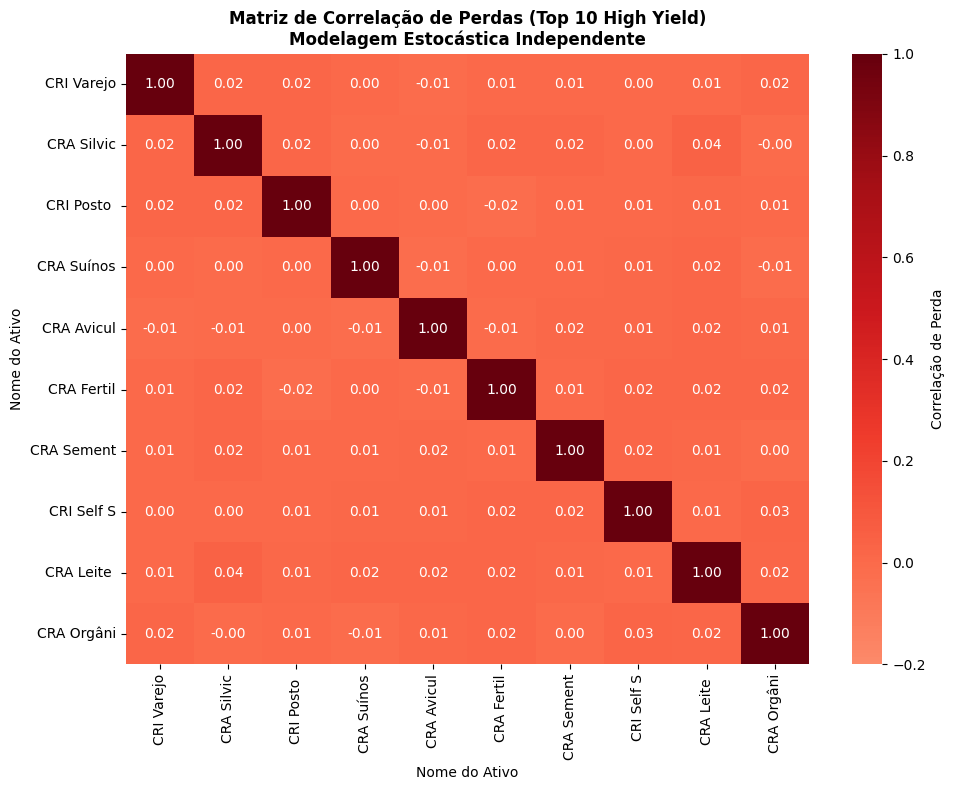


DIAGNÓSTICO CONCLUÍDO: Se a convergência do CDI está próxima de 0 erro, e os calotes simulados
batem com a PD teórica, o motor estocástico está pronto para a Otimização CVaR (PuLP).


In [ ]:
import seaborn as sns 
from scipy.stats import skew, kurtosis

# ==========================================
# DIAGNÓSTICO: VALIDAÇÃO DO MONTE CARLO E MATRIZ DE PERDAS (CVaR)
# ==========================================
print("="*80)
print(" VERIFICAÇÃO DE INTEGRIDADE - MOTOR ESTOCÁSTICO E MATRIZ DE PERDAS ")
print("="*80)

# Teste 1: INTEGRIDADE DA MATRIZ (Ruído Crítico: NaN/Inf)
print("\n✓ TESTE 1: Checando Ruído (NaN, Inf) na Matriz de Perdas")
print("-" * 80)
n_nan = np.isnan(matriz_perdas).sum()
n_inf = np.isinf(matriz_perdas).sum()
status = "✓ OK" if (n_nan == 0 and n_inf == 0) else "⚠ ALERTA CRÍTICO"
print(f"Total de Valores na Matriz: {matriz_perdas.size} ({matriz_perdas.shape[0]} Cenários x {matriz_perdas.shape[1]} Ativos)")
print(f"Valores NaN: {n_nan} | Valores Inf: {n_inf} | Status: {status}")

# Teste 2: VALIDAÇÃO MACROECONÔMICA (CDI Simulado vs Esperado)
print("\n✓ TESTE 2: Convergência do Fator Macro (CDI)")
print("-" * 80)
cdi_simulado_medio = np.mean(cdi_anualizado_cenarios)
cdi_simulado_std = np.std(cdi_anualizado_cenarios)
erro_cdi = abs(cdi_simulado_medio - CDI_MEDIO_ESPERADO) / CDI_MEDIO_ESPERADO
print(f"CDI Médio Teórico:   {CDI_MEDIO_ESPERADO*100:.4f}% a.a.")
print(f"CDI Médio Simulado:  {cdi_simulado_medio*100:.4f}% a.a.")
print(f"Volatilidade Sim:    {cdi_simulado_std*100:.4f}%")
print(f"Erro de Convergência:{erro_cdi*100:.4f}% -> {'✓ Excelente' if erro_cdi < 0.05 else '⚠ Baixa convergência (aumente S)'}")

# Teste 3: VALIDAÇÃO DO RISCO DE CRÉDITO (Calotes Simulados vs PD Acumulada)
print("\n✓ TESTE 3: Convergência do Risco de Crédito (Calotes)")
print("-" * 80)
# Vamos pegar 3 ativos de amostra (Melhor, Médio e Pior Rating) para validar se a máquina quebrou eles corretamente
indices_amostra = [
    df_ltv['Prob_Default_Anual'].argmin(), # Ativo mais seguro
    len(df_ltv) // 2,                      # Ativo do meio
    df_ltv['Prob_Default_Anual'].argmax()  # Ativo mais arriscado
]

for idx in indices_amostra:
    nome = df_ltv.loc[idx, 'Nome do Ativo']
    rating = df_ltv.loc[idx, 'Rating Interno']
    pd_teorica = pd_acumulada[idx]
    
    # Quantas vezes este ativo quebrou nos 2000 cenários?
    calotes_simulados = matriz_calotes[:, idx].sum()
    pd_simulada = calotes_simulados / S
    
    print(f"Ativo: {nome[:15]:15s} | Rating: {rating:4s} | PD Teórica 3A: {pd_teorica*100:6.2f}% | Quebras: {calotes_simulados:4d}/{S} ({pd_simulada*100:5.2f}%)")

# Teste 4: ESTATÍSTICAS DA CAUDA (Assimetria e Curtose da Matriz de Perdas)
print("\n✓ TESTE 4: Diagnóstico de Risco de Cauda (Skewness & Kurtosis)")
print("-" * 80)
print("No modelo CVaR, esperamos alta Assimetria (Skewness), pois perdas de calote são extremas.")
perda_media_ativos = np.mean(matriz_perdas, axis=0)
assimetria_ativos = skew(matriz_perdas, axis=0)
curtose_ativos = kurtosis(matriz_perdas, axis=0)

print(f"{'Métrica':<20} | {'Média dos Ativos':<15} | {'Max (Pior Ativo)':<15}")
print(f"{'Perda Média':<20} | {np.mean(perda_media_ativos):.4f}          | {np.max(perda_media_ativos):.4f}")
print(f"{'Assimetria (Skew)':<20} | {np.mean(assimetria_ativos):.4f}          | {np.max(assimetria_ativos):.4f} -> Cauda Gorda Positiva (Risco de Quebra)")

# Teste 5: Heatmap das correlações de perdas entre os ativos - Os calotes estão correlacionados? (Risco Sistêmico)
print("\n✓ TESTE 5: Correlação de Perdas entre os 10 Maiores Ativos")
print("-" * 80)
# Pegamos os 10 ativos com maior spread para ver se eles quebram juntos
top_10_idx = np.argsort(spreads_dec)[-10:]
matriz_perdas_top10 = matriz_perdas[:, top_10_idx]
df_perdas_top10 = pd.DataFrame(matriz_perdas_top10, columns=df_ltv.loc[top_10_idx, 'Nome do Ativo'].str[:10])

corr_perdas = df_perdas_top10.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_perdas, annot=True, cmap='Reds', center=0, vmin=-0.2, vmax=1, fmt=".2f",
            cbar_kws={'label': 'Correlação de Perda'})
plt.title('Matriz de Correlação de Perdas (Top 10 High Yield)\nModelagem Estocástica Independente', fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("DIAGNÓSTICO CONCLUÍDO: Se a convergência do CDI está próxima de 0 erro, e os calotes simulados")
print("batem com a PD teórica, o motor estocástico está pronto para a Otimização CVaR (PuLP).")
print("="*80)

In [19]:
# ==============================================================================
# ENTREGÁVEL 1: MÉTRICAS CONSOLIDADAS (BASEADO NO MODELO CVaR)
# ==============================================================================
print("Processando Métricas Consolidadas do Modelo Estocástico (CVaR)...")

# 1. ENRIQUECIMENTO DOS DADOS
# Cruzamos a carteira CVaR com a base original para resgatar a Duration e Liquidez
df_entrega_cvar = pd.merge(
    df_carteira_cvar, 
    df_ltv[['Nome do Ativo', 'Duration (anos)', 'Liquidez_Norm']], 
    left_on='Nome', 
    right_on='Nome do Ativo', 
    how='left'
)

# Convertendo peso para decimal para a matemática
pesos_dec_cvar = df_entrega_cvar['Peso (%)'] / 100
capital_total = 50_000_000

# ==========================================
# 2. CÁLCULO DAS MÉTRICAS PONDERADAS
# ==========================================
num_ativos_cvar = len(df_entrega_cvar)

# Médias Ponderadas rigorosas
spread_medio_ponderado = np.average(df_entrega_cvar['Spread'], weights=pesos_dec_cvar)
duration_media_ponderada = np.average(df_entrega_cvar['Duration (anos)'], weights=pesos_dec_cvar)
retorno_esperado_ponderado = np.average(df_entrega_cvar['Retorno Esperado (%)'], weights=pesos_dec_cvar)

# Rating Médio Ponderado
rating_map = {'AAA': 10, 'AA': 9, 'A': 8, 'A-': 7, 'BBB': 6, 'BB+': 5, 'BB': 4, 'BB-': 3, 'B+': 2, 'B': 1, 'B-': 0}
rating_map_inverso = {v: k for k, v in rating_map.items()}

scores_rating = df_entrega_cvar['Rating'].map(rating_map).fillna(5)
score_medio_ponderado = np.average(scores_rating, weights=pesos_dec_cvar)
rating_medio_carteira = rating_map_inverso.get(round(score_medio_ponderado), "N/A")

# ==========================================
# 3. CONCENTRAÇÃO DA CARTEIRA
# ==========================================
dist_setor = df_entrega_cvar.groupby('Setor')['Peso (%)'].sum().sort_values(ascending=False).round(2)
dist_rating = df_entrega_cvar.groupby('Rating')['Peso (%)'].sum().sort_values(ascending=False).round(2)

# ==============================================================================
# 4. EXIBIÇÃO DO RESUMO EXECUTIVO (FORMATO TERMINAL)
# ==============================================================================
print("\n" + "="*70)
print(" ENTREGÁVEL 1: RESUMO EXECUTIVO DA CARTEIRA CVaR (ROCKAFELLAR)")
print("="*70)
print(f"Capital Total Alocado:  R$ {capital_total:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.'))
print(f"Quantidade de Ativos:   {num_ativos_cvar} Emissores")
print("-" * 70)
print(f"Retorno Médio Esperado: {retorno_esperado_ponderado:.2f}% a.a. (Simulado)")
print(f"Spread Médio Ponderado: {spread_medio_ponderado:.0f} bps")
print(f"Duration Média Pond.:   {duration_media_ponderada:.2f} anos")
print(f"Rating Médio Ponderado: {rating_medio_carteira} (Score: {score_medio_ponderado:.2f})")
print("="*70)

print("\n--- CONCENTRAÇÃO POR SETOR ---")
display(pd.DataFrame({'Alocação Total (%)': dist_setor}))

print("\n--- CONCENTRAÇÃO POR RATING ---")
display(pd.DataFrame({'Alocação Total (%)': dist_rating}))

# ==============================================================================
# 5. GERAÇÃO DO ARQUIVO EXCEL FINAL
# ==============================================================================
caminho_saida_cvar = r"C:\Users\henri\.vscode\vscode\Finanças + Python\Base de Dados Finanças\Entregavel_1_CVaR_Metricas.xlsx"

# Montagem do Dashboard em formato de Tabela
df_resumo = pd.DataFrame({
    'Métrica Principal': ['Capital Total', 'Quantidade de Ativos', 'Retorno Esperado (% a.a.)', 'Spread Médio (bps)', 'Duration Média (anos)', 'Rating Médio da Carteira'],
    'Valor': [f"R$ {capital_total:,.2f}", num_ativos_cvar, round(retorno_esperado_ponderado, 2), round(spread_medio_ponderado, 0), round(duration_media_ponderada, 2), rating_medio_carteira]
})

try:
    with pd.ExcelWriter(caminho_saida_cvar) as writer:
        df_resumo.to_excel(writer, sheet_name='Resumo Executivo', index=False)
        # Removemos colunas redundantes antes de salvar
        if 'Nome do Ativo' in df_entrega_cvar.columns:
            df_entrega_cvar = df_entrega_cvar.drop(columns=['Nome do Ativo'])
            
        df_entrega_cvar.to_excel(writer, sheet_name='Carteira Otimizada CVaR', index=False)
        pd.DataFrame({'Setor': dist_setor.index, 'Peso (%)': dist_setor.values}).to_excel(writer, sheet_name='Concentração Setorial', index=False)
        pd.DataFrame({'Rating': dist_rating.index, 'Peso (%)': dist_rating.values}).to_excel(writer, sheet_name='Concentração Rating', index=False)
    
    print(f"\n✅ SUCESSO! O arquivo do Entregável 1 (Modelo CVaR) foi salvo perfeitamente com todas as abas em:\n-> {caminho_saida_cvar}")
except Exception as e:
    print(f"\n⚠ Erro ao salvar o Excel. Verifique se o arquivo '{caminho_saida_cvar}' não está aberto no momento: {e}")

Processando Métricas Consolidadas do Modelo Estocástico (CVaR)...

 ENTREGÁVEL 1: RESUMO EXECUTIVO DA CARTEIRA CVaR (ROCKAFELLAR)
Capital Total Alocado:  R$ 50.000.000,00
Quantidade de Ativos:   20 Emissores
----------------------------------------------------------------------
Retorno Médio Esperado: 13.57% a.a. (Simulado)
Spread Médio Ponderado: 379 bps
Duration Média Pond.:   2.48 anos
Rating Médio Ponderado: A (Score: 7.86)

--- CONCENTRAÇÃO POR SETOR ---


,Alocação Total (%)
Setor,
Comercial,23.84
Agronegócio,20.93
Logística,15.93
Residencial,10.11
Industrial,6.27
Educação,5.34
Infraestrutura,4.72
Varejo/Shopping,4.36
Autoarmazenagem,3.59



--- CONCENTRAÇÃO POR RATING ---


,Alocação Total (%)
Rating,
A,28.81
A-,26.84
AAA,18.70
BBB,12.73
AA,10.22
BB+,1.96
BB,0.75



✅ SUCESSO! O arquivo do Entregável 1 (Modelo CVaR) foi salvo perfeitamente com todas as abas em:
-> C:\Users\henri\.vscode\vscode\Finanças + Python\Base de Dados Finanças\Entregavel_1_CVaR_Metricas.xlsx


In [ ]:
S = 10000
Anos = 3
CDI_MEDIO_ESPERADO = 0.105
VOLATILIDADE_CDI = 0.02
LGD = 0.50
np.random.seed(42) 
num_ativos_total = len(df_ltv)
spreads_dec = df_ltv['Spread (bps)'].values / 10000
pd_acumulada = 1 - (1 - df_ltv['Prob_Default_Anual'].values)**Anos
cdi_por_ano = np.random.normal(CDI_MEDIO_ESPERADO, VOLATILIDADE_CDI, (S, Anos))
cdi_anualizado_cenarios = np.prod(1 + cdi_por_ano, axis=1)**(1/Anos) - 1
retorno_pagamento_aa = cdi_anualizado_cenarios[:, np.newaxis] + spreads_dec
retorno_calote_aa = (1 - LGD)**(1/Anos) - 1

matriz_calotes = np.random.rand(S, num_ativos_total) < pd_acumulada
matriz_retornos = np.where(matriz_calotes, retorno_calote_aa, retorno_pagamento_aa)

matriz_perdas = -matriz_retornos
retorno_esperado_ativos = np.mean(matriz_retornos, axis=0)

print(f"Monte Carlo concluído! Matriz de Perdas gerada: {matriz_perdas.shape[0]} Cenários x {matriz_perdas.shape[1]} Ativos.")

1